In [5]:
import numpy as np
import input_parameters as parmt
import matplotlib.pyplot as plt
import matplotlib.colors
from epsilon_routines import epsilon_r, kramerskronig
from binning import gen_bin_centers, spherical_to_cartesian

#%matplotlib inline

mElectron = 5.1099894e5
alpha = 1.0/137.03599908

In [38]:
#RPA
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_1q_200E_old.npy') #6x6x6 -> 6x6x6
bin_centers = gen_bin_centers(q_max=1)
eps = epsilon_r(bin_centers, binned_eps)

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_46_bg1.10_1q_50E_old.npy') #4x4x4 -> 6x6x6
bin_centers = gen_bin_centers(q_max=1)
eps_46 = epsilon_r(bin_centers, binned_eps)

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_68_bg1.10_1q_50E_old.npy') #6x6x6 -> 8x8x8
bin_centers = gen_bin_centers(q_max=1)
eps_68 = epsilon_r(bin_centers, binned_eps)

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_8_bg1.10_1q_50E_old.npy') #8x8x8 -> 8x8x8
bin_centers = gen_bin_centers(q_max=1)
eps_8 = epsilon_r(bin_centers, binned_eps)

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_5q_50E_old.npy') #6x6x6 -> 6x6x6
bin_centers = gen_bin_centers(q_max=5)
eps_6_5q = epsilon_r(bin_centers, binned_eps)

binned_eps = np.load('test_resources/binned_eps/cc-pvdz_pbe_6_bg1.10_1q_50E_tz_6_old.npy') #6x6x6 -> 6x6x6
bin_centers = gen_bin_centers(q_max=1)
eps_6_dz = epsilon_r(bin_centers, binned_eps)

/home/meganhott/Research/dielectric_pyscf/epsilon_routines.py:258: RuntimeWarning: invalid value encountered in divide
  eps_r[i] = np.nansum(eps_ri, axis=0) / (N_ang_bins - np.sum(np.isnan(eps_ri).astype(int), axis=0)) #treats nans as 0, want to average over all non-nan entries


In [39]:
#RPA Kramers-Kronig 

def kk_1d(eps, E, n_q, corr=False):
    eps_im = np.imag(eps[n_q,:])
    eps_re = np.zeros_like(eps_im)
    for n, En in enumerate(E):
        E_pv = np.delete(E, n) #removes Ei = En for principal value
        eps_re[n] = 2/np.pi*parmt.dE*(sum([Ei*eps_im[i]/(Ei**2-En**2) for i,Ei in enumerate(E_pv)]) - 0.5*(E_pv[0]*eps_im[0]/(E_pv[0]**2-En**2) + E_pv[-1]*eps_im[-1]/(E_pv[-1]**2-En**2)))#trapezoid rule
    if corr:
        eps_re = eps_re*10 #correction factor is 1/parmt.dE = 10, not 4pi
    return eps_re + 1

def kk_2d(eps, E, n_E, corr=False):
    eps_im = np.imag(eps)
    eps_re = np.zeros((eps_im.shape[0], n_E))
    for n, En in enumerate(E[:n_E]):
        E_pv = np.delete(E, n) #removes Ei = En for principal value
        eps_im_pv = np.delete(eps_im, n, axis=1)

        eps_re[:,n] = 2/np.pi*parmt.dE*(np.sum(E_pv[None,:] * eps_im_pv / (E_pv[None,:]**2 - En**2), axis=1) - 0.5*(E_pv[None,0]*eps_im_pv[:,0]/(E_pv[None,0]**2-En**2) + E_pv[None,-1]*eps_im_pv[:,-1]/(E_pv[None,-1]**2-En**2))) #trapezoid rule
    if corr:
        eps_re = eps_re*10 #correction factor is 1/parmt.dE = 10, not 4pi
    return eps_re + 1


In [40]:
#DarkELF
import sys
import os
sys.path.append(os.getcwd()+'/../DarkELF')
from darkelf import darkelf, targets

darkelf_gpaw = darkelf(target='Si', filename='Si_gpaw_noLFE.dat')

 .... Loading files for Si
Loaded Si_gpaw_noLFE.dat for epsilon in electron regime
electronic ELF taken or calculated from J. Enkovaara et al.,Electronic structure calculations with GPAW: a real-space implementation of the projector augmented-wave method,Journal of Physics:Condensed Matter22(2010) 253202.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, “Intensity of diffracted intensities,” in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554–595, https://onlinelibrary.wiley.com/doi/pdf/10.1107/97809553602060000
Loaded /home/meganhott/Research/dielectric_pyscf/../DarkELF/darkelf/../data/Si/Si_pDoS.dat for partial densi

In [41]:
#Lindhard model
VCell = 5.209e-9
nValence = 8
MCell = 52322355000.0
mElectron = 5.1099894e5
alpha = 1.0/137.03599908

def Lindhard(om, q, fp): #energy, q, 
    q = q*alpha*mElectron #convert q from ame to eV
    def plog(x):
        return np.log(np.abs(x)) + 1j*np.angle(x)
    ne = nValence/VCell
    kF = (3*np.pi**2*ne)**(1./3.)
    omp = np.sqrt(4*np.pi*alpha*ne/mElectron)
    vF = kF/mElectron
    Gp = fp*omp
    Qp = q/(2*kF) + (om + 1j*Gp)/(q*vF)
    Qm = q/(2*kF) - (om + 1j*Gp)/(q*vF)
    factor1 = 3*(omp**2)/(q**2)/(vF**2)
    factor2 = 0.5 + kF/(4*q)*(1-Qm**2)*plog((Qm+1)/(Qm-1)) + kF/(4*q)*(1-Qp**2)*plog((Qp+1)/(Qp-1))
    return 1 + factor1*factor2

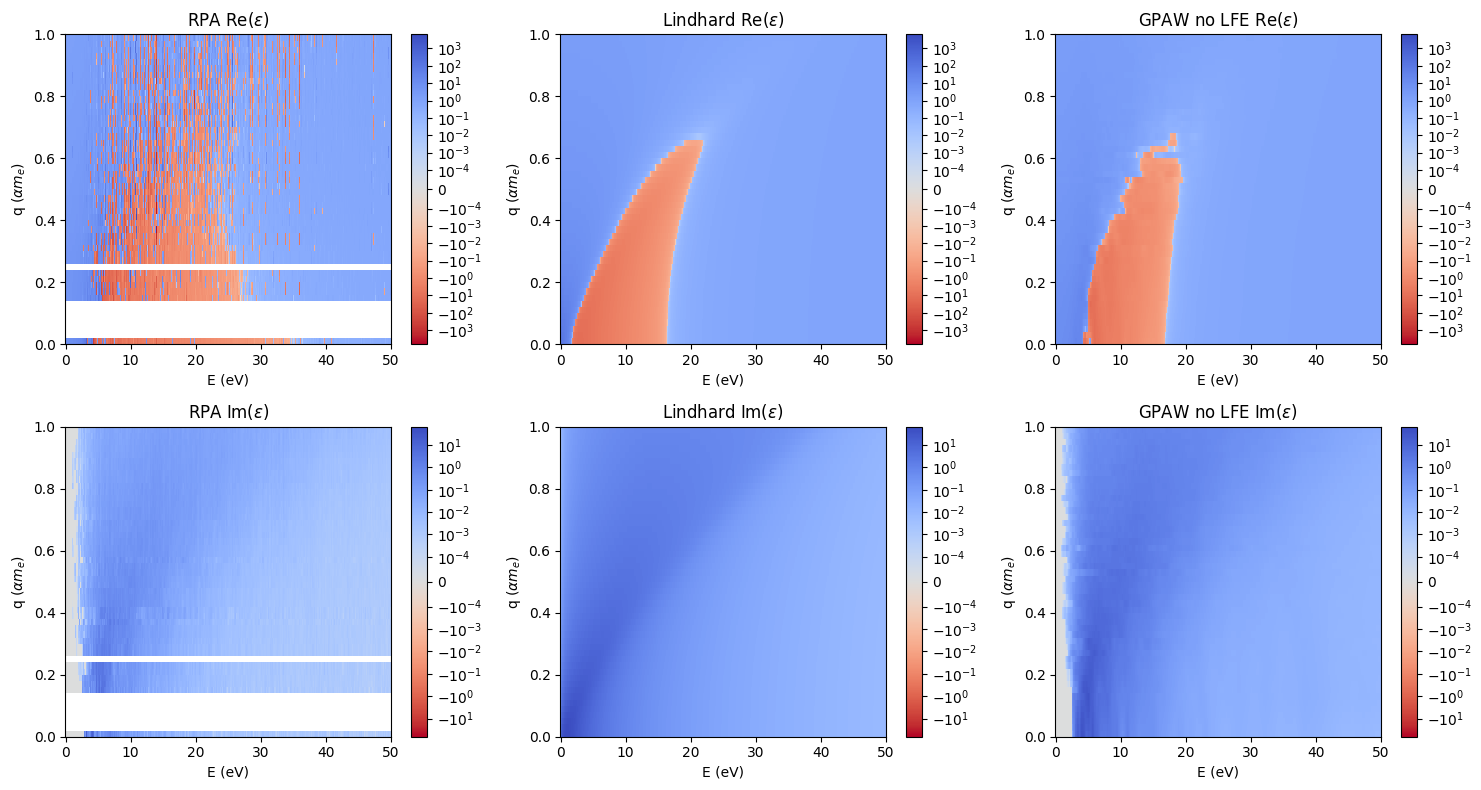

In [42]:
#Full Re and Im Plots
q = np.arange(0.01, 1, parmt.dq) #alpha me
E = np.arange(0, 200+parmt.dE, parmt.dE) #eV

E_mesh, q_mesh = np.meshgrid(E, q)
eps_l = Lindhard(E_mesh, q_mesh, 0.1)

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.concatenate([np.real(eps[np.invert(np.isnan(eps))]), np.real(eps_l[np.invert(np.isnan(eps_l))])]))
re_max = np.max(np.concatenate([np.real(eps[np.invert(np.isnan(eps))]), np.real(eps_l[np.invert(np.isnan(eps_l))])]))
im_min = np.min(np.concatenate([np.imag(eps[np.invert(np.isnan(eps))]), np.imag(eps_l[np.invert(np.isnan(eps_l))])]))
im_max = np.max(np.concatenate([np.imag(eps[np.invert(np.isnan(eps))]), np.imag(eps_l[np.invert(np.isnan(eps_l))])]))
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(2,3, figsize=(15,8))

im0 = ax[(0,0)].pcolormesh(E[:501], q, np.real(eps[:,:501]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,0)].pcolormesh(E[:501], q, np.imag(eps[:,:501]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,))
im2 = ax[(0,1)].pcolormesh(E[:501], q, np.real(eps_l[:,:501]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E[:501], q, np.imag(eps_l[:,:501]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,))
im4 = ax[(0,2)].pcolormesh(E[:501], q, darkelf_gpaw.eps1(E[:501], q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im5 = ax[(1,2)].pcolormesh(E[:501], q, darkelf_gpaw.eps2(E[:501], q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
"""
im0 = ax[(0,0)].imshow(np.real(eps_l), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max), origin='lower')
"""
fig.colorbar(im0, ax=ax[(0,0)])
fig.colorbar(im1, ax=ax[(1,0)])
ax[(0,0)].set_title(r'RPA Re($\epsilon$)')
ax[(1,0)].set_title(r'RPA Im($\epsilon$)')
#ax[(1,0)].axvline(x=1.12, ymin=0, ymax=1, color='k', linestyle='--')
fig.colorbar(im2, ax=ax[(0,1)])
fig.colorbar(im3, ax=ax[(1,1)])
ax[(0,1)].set_title(r'Lindhard Re($\epsilon$)')
ax[(1,1)].set_title(r'Lindhard Im($\epsilon$)')
fig.colorbar(im4, ax=ax[(0,2)])
fig.colorbar(im5, ax=ax[(1,2)])
ax[(0,2)].set_title(r'GPAW no LFE Re($\epsilon$)')
ax[(1,2)].set_title(r'GPAW no LFE Im($\epsilon$)')

for i in [0,1]:
    for j in [0,1,2]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

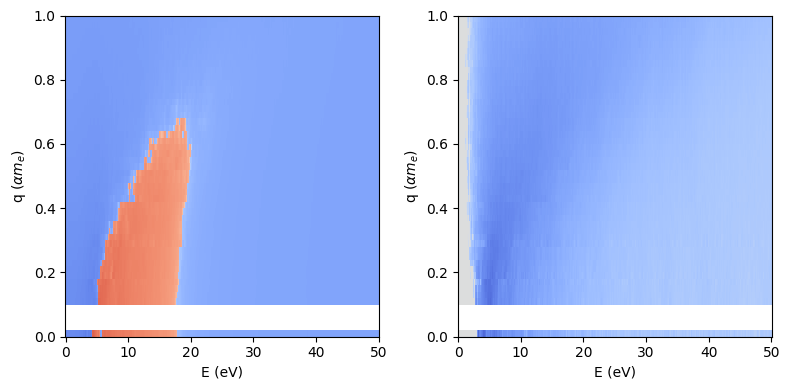

In [43]:
#Re(eps) from Kramers-Kronig
fig, ax = plt.subplots(1,2, figsize=(8,4))
q_5 = np.arange(0.01, 5, parmt.dq) #alpha me
E_50 = np.arange(0, 50+parmt.dE, parmt.dE) #eV

eps_8_kk = kk_2d(eps_8, E_50, 501, corr=True)

im0 = ax[0].pcolormesh(E_50, q, eps_8_kk, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[1].pcolormesh(E_50, q, np.imag(eps_8), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,))

for i in [0,1]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

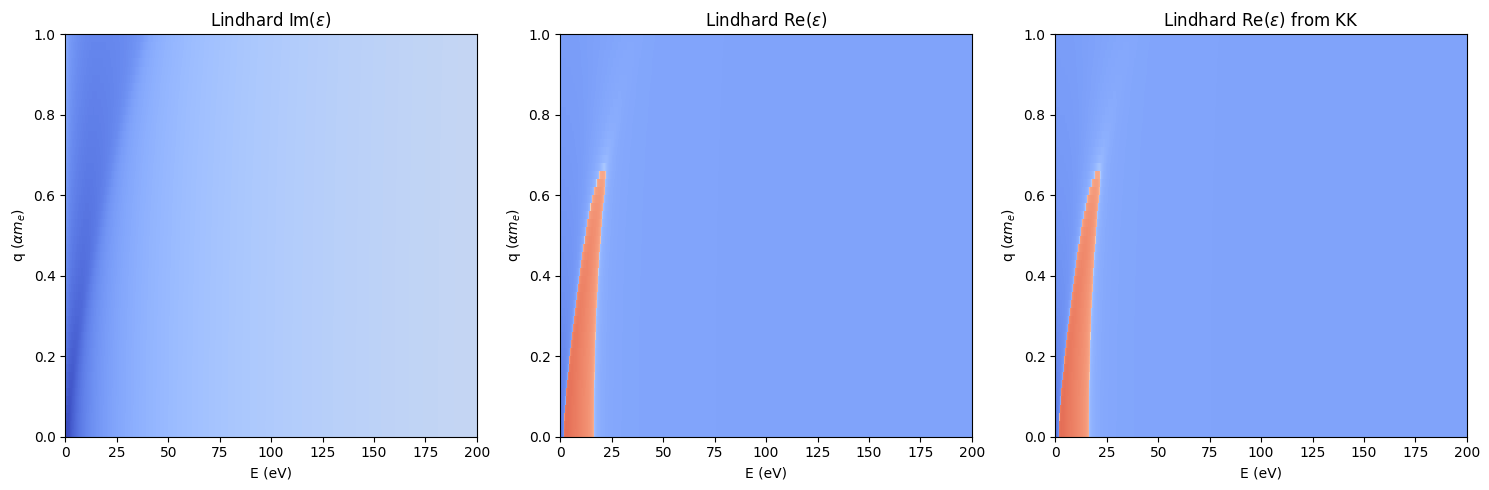

In [44]:
#Testing Kramers-Kronig with Lindhard

E_l = np.arange(0, 500+parmt.dE, parmt.dE)
E_mesh_l, q_mesh_l = np.meshgrid(E_l, q)
eps_l_large = Lindhard(E_mesh_l, q_mesh_l, 0.1)

eps_kk_l_re = kk_2d(eps_l, E, E.shape[0]) #still looks accurate only inlcuding energies up to 50eV

fig, ax = plt.subplots(1,3, figsize=(15,5))
im0 = ax[0].pcolormesh(E, q, np.imag(eps_l), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[1].pcolormesh(E, q, np.real(eps_l), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[2].pcolormesh(E, q, eps_kk_l_re[:,:E.shape[0]], cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[0].set_title(r'Lindhard Im($\epsilon$)')
ax[1].set_title(r'Lindhard Re($\epsilon$)')
ax[2].set_title(r'Lindhard Re($\epsilon$) from KK')
for i in [0,1,2]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

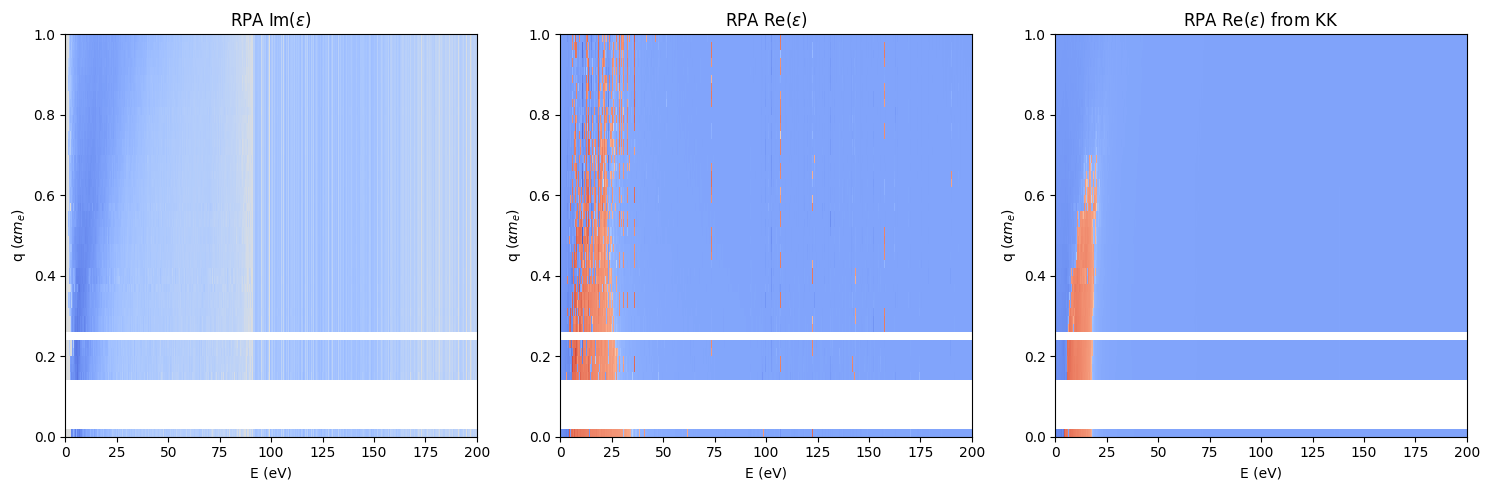

In [45]:
#Kramers-Kronig RPA
eps_kk_re = kk_2d(eps, E, E.shape[0], corr=True)

fig, ax = plt.subplots(1,3, figsize=(15,5))
im0 = ax[0].pcolormesh(E, q, np.imag(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[1].pcolormesh(E, q, np.real(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[2].pcolormesh(E, q, eps_kk_re, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
#Note modification to Re from KK in last plot - could we get something reasonable if constant multiplying chi is fixed?

ax[0].set_title(r'RPA Im($\epsilon$)')
ax[1].set_title(r'RPA Re($\epsilon$)')
ax[2].set_title(r'RPA Re($\epsilon$) from KK')
for i in [0,1,2]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

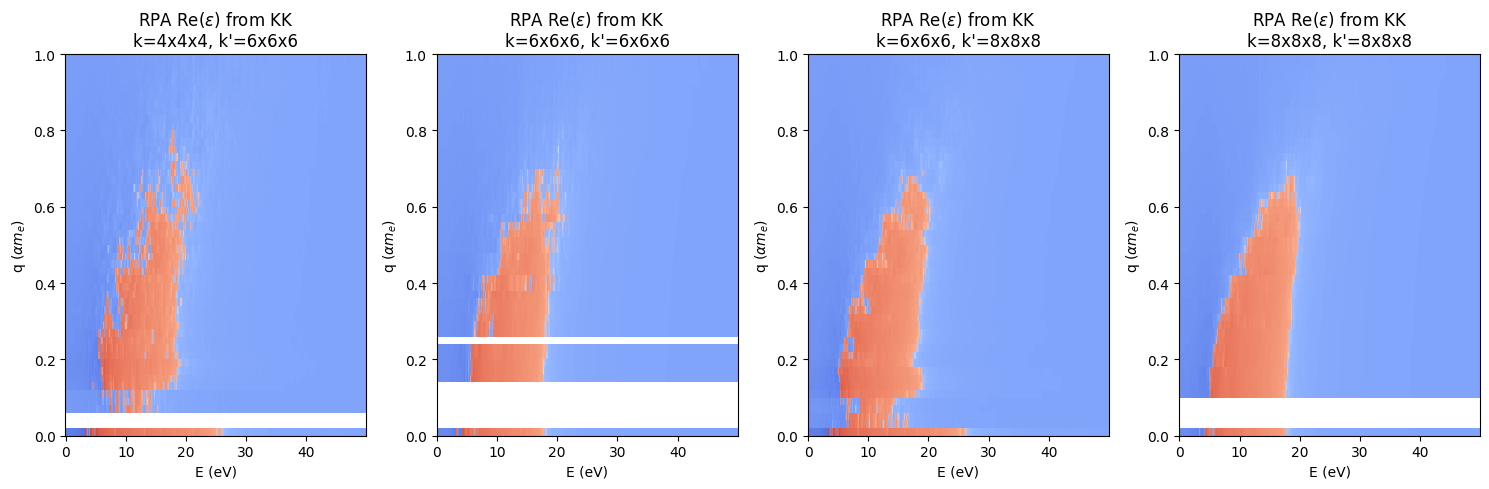

In [46]:
#Kramers-Kronig RPA
eps_kk_re_50 = kk_2d(eps[:,:501], E[:501], 500, corr=True) #only using data up to 50eV in KK
eps_kk_re_46 = kk_2d(eps_46, E[:501], 500, corr=True) 
eps_kk_re_68 = kk_2d(eps_68, E[:501], 500, corr=True) 
eps_kk_re_8 = kk_2d(eps_8, E[:501], 500, corr=True)

fig, ax = plt.subplots(1, 4, figsize=(15,5))
#im0 = ax[0].pcolormesh(E[:int(50/parmt.dE)], q, np.real(eps[:,:int(50/parmt.dE)]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im0 = ax[0].pcolormesh(E[:int(50/parmt.dE)], q, eps_kk_re_46, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[1].pcolormesh(E[:int(50/parmt.dE)], q, eps_kk_re_50, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[2].pcolormesh(E[:int(50/parmt.dE)], q, eps_kk_re_68, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[3].pcolormesh(E[:int(50/parmt.dE)], q, eps_kk_re_8, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[0].set_title(r'RPA Re($\epsilon$) from KK'+'\n'+"k=4x4x4, k'=6x6x6")
ax[1].set_title(r'RPA Re($\epsilon$) from KK'+'\n'+"k=6x6x6, k'=6x6x6")
ax[2].set_title(r'RPA Re($\epsilon$) from KK'+'\n'+"k=6x6x6, k'=8x8x8")
ax[3].set_title(r'RPA Re($\epsilon$) from KK'+'\n'+"k=8x8x8, k'=8x8x8")
for i in [0,1,2,3]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

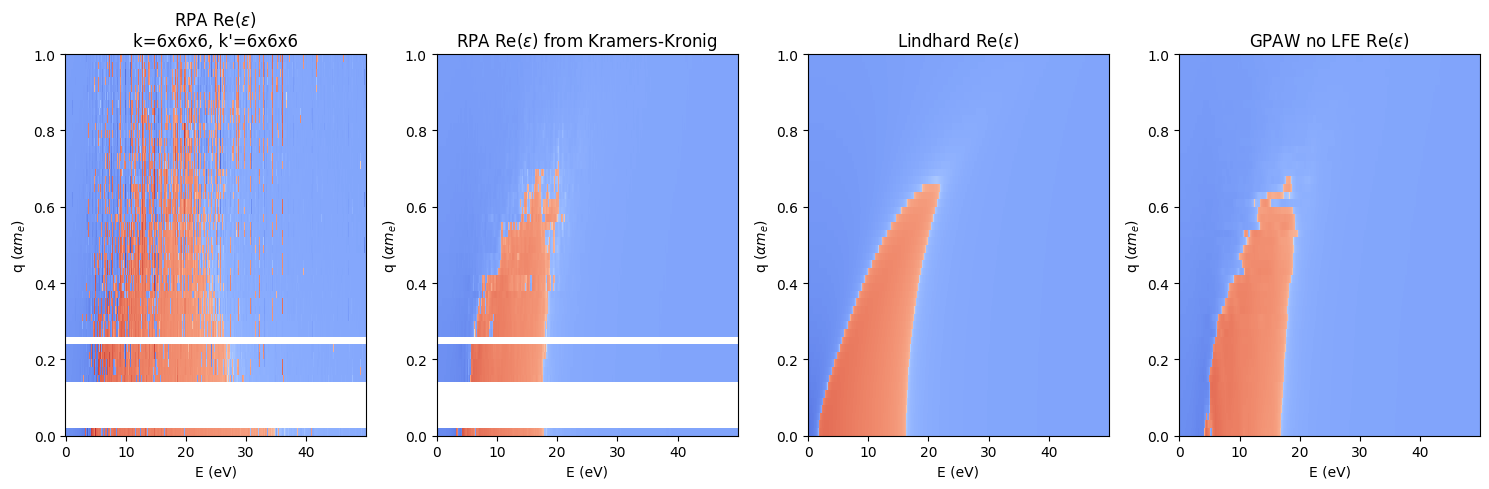

In [47]:
#Comparing Re(RPA)
fig, ax = plt.subplots(1, 4, figsize=(15,5))
im0 = ax[0].pcolormesh(E[:int(50/parmt.dE)], q, np.real(eps[:,:int(50/parmt.dE)]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[1].pcolormesh(E[:int(50/parmt.dE)], q, eps_kk_re[:,:int(50/parmt.dE)], cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[2].pcolormesh(E[:int(50/parmt.dE)], q, np.real(eps_l[:,:int(50/parmt.dE)]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max,))
im3 = ax[3].pcolormesh(E[:int(50/parmt.dE)], q, darkelf_gpaw.eps1(E[:int(50/parmt.dE)], q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[0].set_title(r'RPA Re($\epsilon$)'+'\n'+"k=6x6x6, k'=6x6x6")
ax[1].set_title(r'RPA Re($\epsilon$) from Kramers-Kronig')
ax[2].set_title(r'Lindhard Re($\epsilon$)')
ax[3].set_title(r'GPAW no LFE Re($\epsilon$)')
for i in [0,1,2,3]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

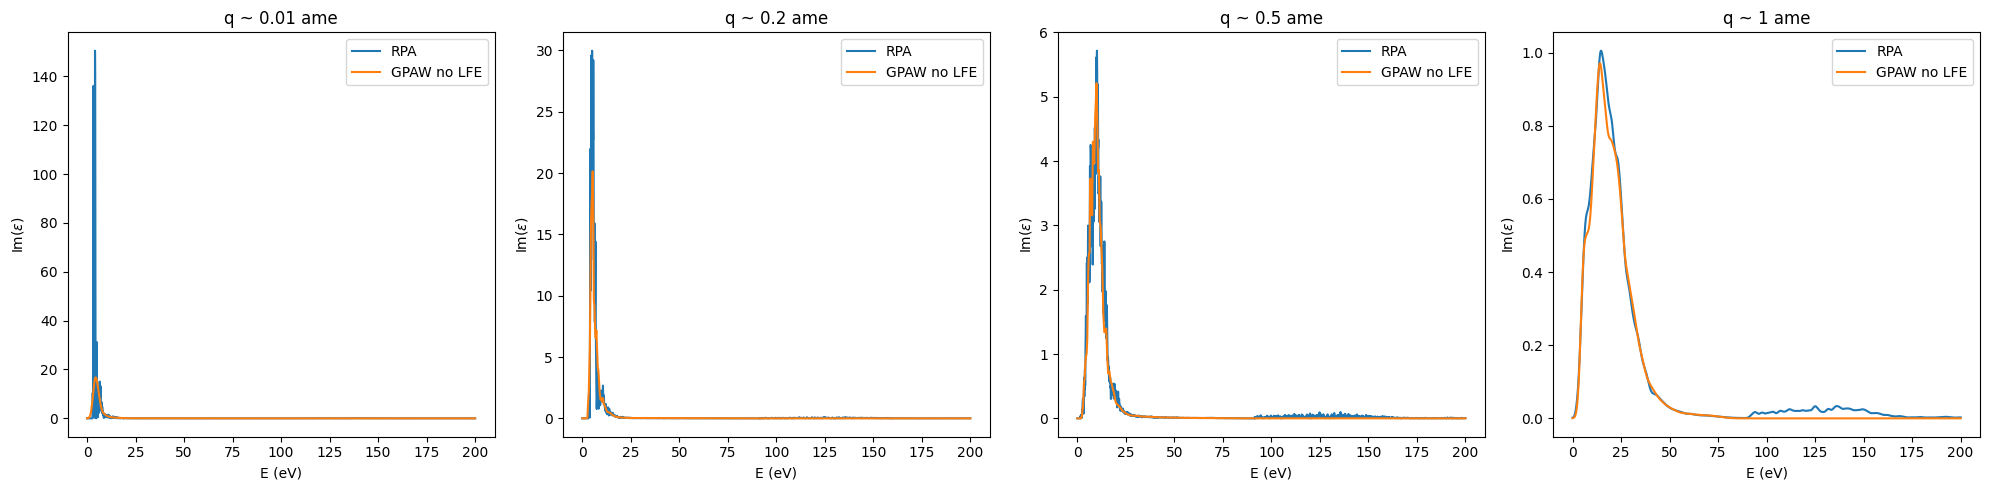

In [50]:
#Im plots
from scipy.ndimage import gaussian_filter1d

#Nonlinear factor to make RPA match GPAW and Lindhard

fig, ax = plt.subplots(1,4, figsize=(20,5))
ax[0].plot(E, 10*np.imag(eps[0,:]), label='RPA')
#ax[0].plot(E, 4*np.pi*gaussian_filter1d(np.imag(eps[0,:]),10), label='Smoothed RPA')
ax[0].plot(E, gaussian_filter1d(darkelf_gpaw.eps2(E, 0.01*alpha*mElectron),10), label='GPAW no LFE')
#ax[0].plot(E, np.imag(eps_l[0,:]), label='Lindhard')
ax[0].set_title('q ~ 0.01 ame')
ax[0].legend()

ax[1].plot(E, 10*np.imag(eps[10,:]), label='RPA')
#ax[1].plot(E, 4*np.pi*gaussian_filter1d(np.imag(eps[10,:]),10), label='Smoothed RPA')
ax[1].plot(E, darkelf_gpaw.eps2(E, 0.2*alpha*mElectron), label='GPAW no LFE')
#ax[1].plot(E, np.imag(eps_l[25,:]), label='Lindhard')
ax[1].set_title('q ~ 0.2 ame')
ax[1].legend()

ax[2].plot(E, 10*np.imag(eps[25,:]), label='RPA')
#ax[2].plot(E, 4*np.pi*gaussian_filter1d(np.imag(eps[25,:]),10), label='Smoothed RPA')
ax[2].plot(E, darkelf_gpaw.eps2(E, 0.5*alpha*mElectron), label='GPAW no LFE')
#ax[1].plot(E, np.imag(eps_l[25,:]), label='Lindhard')
ax[2].set_title('q ~ 0.5 ame')
ax[2].legend()

ax[3].plot(E, 10*gaussian_filter1d(np.imag(eps[-1,:]),10), label='RPA')
#ax[3].plot(E, 4*np.pi*gaussian_filter1d(np.imag(eps[-1,:]),10), label='Smoothed RPA')
ax[3].plot(E, gaussian_filter1d(darkelf_gpaw.eps2(E, 1*alpha*mElectron),10), label='GPAW no LFE')
#ax[2].plot(E, np.imag(eps_l[-1,:]), label='Lindhard')
ax[3].set_title('q ~ 1 ame')
ax[3].legend()

for i in [0,1,2,3]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'Im($\epsilon)$')
plt.tight_layout()
plt.show()


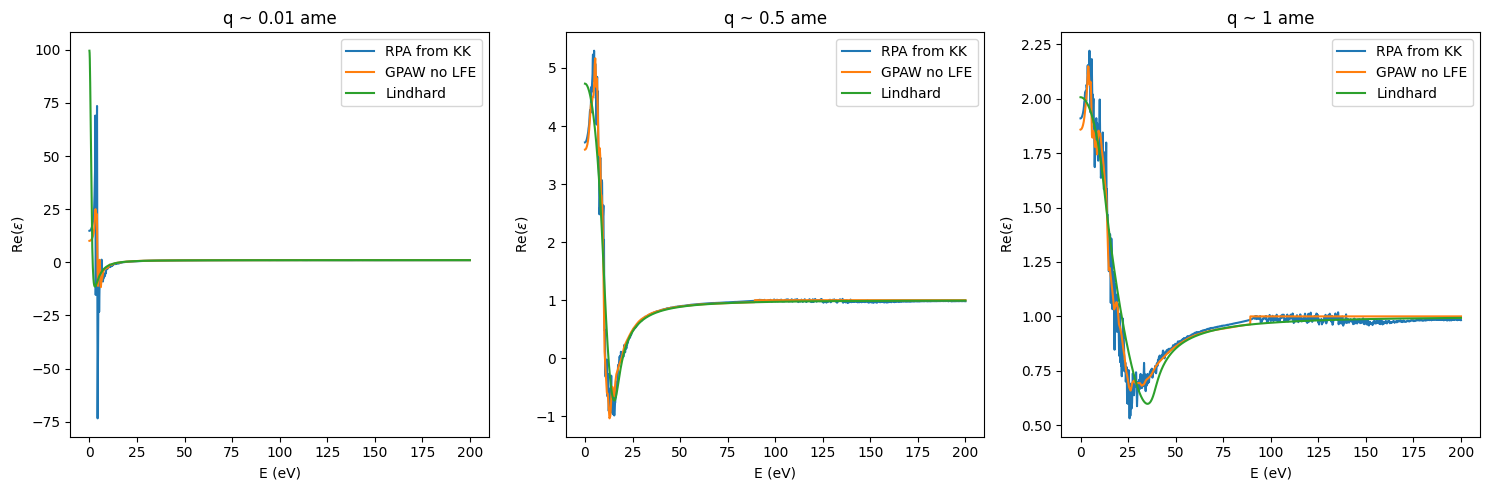

In [52]:
#Re plots

fig, ax = plt.subplots(1,3, figsize=(15,5))
#ax[0].plot(E, gaussian_filter1d(np.real(eps[0,:]),10), label='Smoothed RPA')
ax[0].plot(E, eps_kk_re[0], label='RPA from KK')
ax[0].plot(E, darkelf_gpaw.eps1(E, 0.01*alpha*mElectron), label='GPAW no LFE')
ax[0].plot(E, np.real(eps_l[0,:]), label='Lindhard')
ax[0].set_title('q ~ 0.01 ame')
ax[0].legend()

#ax[1].plot(E, gaussian_filter1d(np.real(eps[25,:]),10), label='Smoothed RPA')
ax[1].plot(E, eps_kk_re[25], label='RPA from KK') 
ax[1].plot(E, darkelf_gpaw.eps1(E, 0.5*alpha*mElectron), label='GPAW no LFE')
ax[1].plot(E, np.real(eps_l[25,:]), label='Lindhard')
ax[1].set_title('q ~ 0.5 ame')
ax[1].legend()

#ax[2].plot(E, gaussian_filter1d(np.real(eps[-1,:]),10), label='Smoothed RPA')
ax[2].plot(E, eps_kk_re[-1], label='RPA from KK')
ax[2].plot(E, darkelf_gpaw.eps1(E, 1*alpha*mElectron), label='GPAW no LFE')
ax[2].plot(E, np.real(eps_l[-1,:]), label='Lindhard')
ax[2].set_title('q ~ 1 ame')
ax[2].legend()

for i in [0,1,2]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'Re($\epsilon)$')
plt.tight_layout()
plt.show()

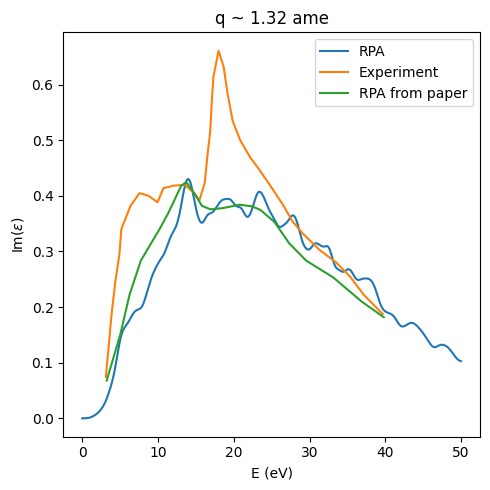

In [53]:
#Compare to experiment
#eps_6_5q
#eps_6_5q_kk = kk_2d(eps_6_5q, E, 501, corr=True)
exp_eps = np.genfromtxt('test_resources/exp_data_im.csv', delimiter=', ')
exp_rpa = np.genfromtxt('test_resources/exp_rpa_no_lfe.csv', delimiter=', ')

fig, ax = plt.subplots(1, figsize=(5,5))
ax.plot(E[:501], 10*gaussian_filter1d(np.imag(eps_6_5q[int(1.32/parmt.dq)]), 5), label='RPA')
ax.plot(exp_eps[:,0], exp_eps[:,1], label='Experiment')
ax.plot(exp_rpa[:,0], exp_rpa[:,1], label='RPA from paper')
#ax.plot(E, darkelf_gpaw.eps1(E, 0.01*alpha*mElectron), label='GPAW no LFE')
#ax.plot(E, np.real(eps_l[0,:]), label='Lindhard')
ax.set_title('q ~ 1.32 ame')
ax.legend()

ax.set_xlabel('E (eV)')
ax.set_ylabel(r'Im($\epsilon)$')
plt.tight_layout()

/home/meganhott/Research/dielectric_pyscf/epsilon_routines.py:258: RuntimeWarning: invalid value encountered in divide
  eps_r[i] = np.nansum(eps_ri, axis=0) / (N_ang_bins - np.sum(np.isnan(eps_ri).astype(int), axis=0)) #treats nans as 0, want to average over all non-nan entries


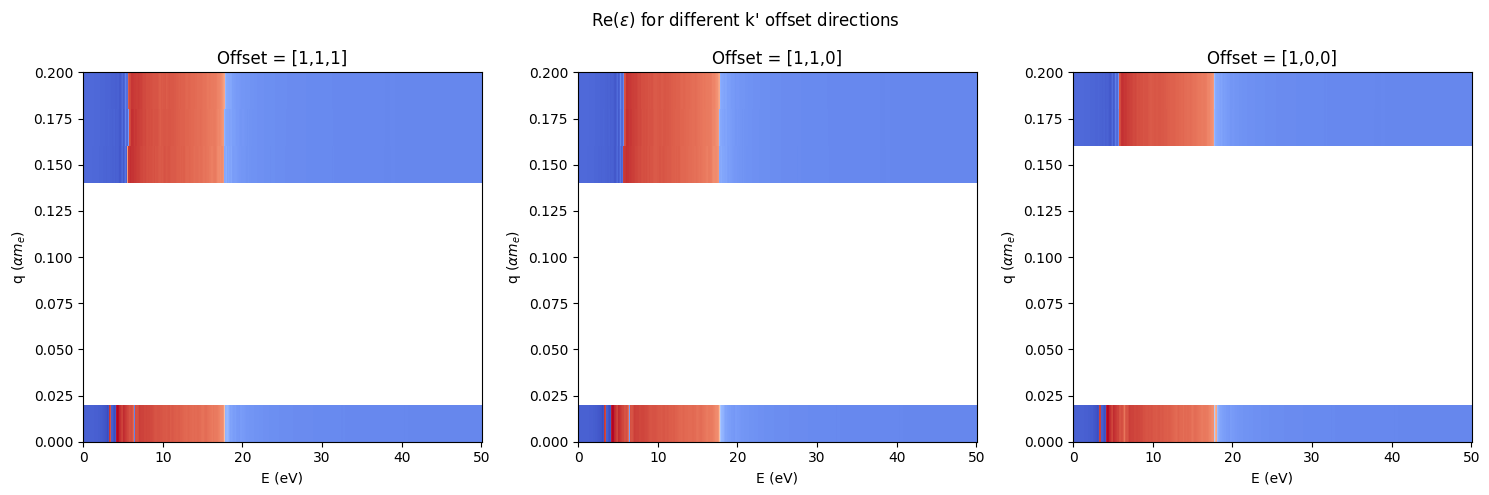

In [54]:
#k' offset in different directions
q = np.arange(0.01, 0.2, parmt.dq) #alpha me
E = np.arange(0, 50+parmt.dE, parmt.dE) #eV

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_0.2q_50E_tz_6_offset111_old.npy')
bin_centers = gen_bin_centers(q_max=0.2)
eps_111 = epsilon_r(bin_centers, binned_eps)
eps_111_kk = kk_2d(eps_111, E, E.shape[0], corr=True)

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_0.2q_50E_tz_6_offset110_old.npy')
bin_centers = gen_bin_centers(q_max=0.2)
eps_110 = epsilon_r(bin_centers, binned_eps)
eps_110_kk = kk_2d(eps_110, E, E.shape[0], corr=True)

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_0.2q_50E_tz_6_offset100_old.npy')
bin_centers = gen_bin_centers(q_max=0.2)
eps_100 = epsilon_r(bin_centers, binned_eps)
eps_100_kk = kk_2d(eps_100, E, E.shape[0], corr=True)

c = 'coolwarm_r'
th = 1e-4
re_min_offset = np.min(np.concatenate([eps_111_kk[np.invert(np.isnan(eps_111_kk))], eps_110_kk[np.invert(np.isnan(eps_110_kk))], eps_100_kk[np.invert(np.isnan(eps_100_kk))]]))
re_max_offset = np.max(np.concatenate([eps_111_kk[np.invert(np.isnan(eps_111_kk))], eps_110_kk[np.invert(np.isnan(eps_110_kk))], eps_100_kk[np.invert(np.isnan(eps_100_kk))]]))
re_max_offset = np.max([re_max_offset, -re_min_offset])

fig, ax = plt.subplots(1, 3, figsize=(15,5))
im0 = ax[0].pcolormesh(E, q, eps_111_kk, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max_offset, vmax=re_max_offset))
im1 = ax[1].pcolormesh(E, q, eps_110_kk, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max_offset, vmax=re_max_offset))
im2 = ax[2].pcolormesh(E, q, eps_100_kk, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max_offset, vmax=re_max_offset))

ax[0].set_title('Offset = [1,1,1]')
ax[1].set_title('Offset = [1,1,0]')
ax[2].set_title('Offset = [1,0,0]')
fig.suptitle(r"Re($\epsilon$) for different k' offset directions")
for i in [0,1,2]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

In [55]:
#New version of code: testing kramers-kronig pre/post angular averaging - gives similar results (Note these are off by prefactor)
q = np.arange(0.01, 1, parmt.dq) #alpha me
E = np.arange(0, 50+parmt.dE, parmt.dE) #eV

binned_eps = np.load('test_resources/binned_eps.npy') #6x6x6 -> 6x6x6
bin_centers = gen_bin_centers(q_max=1)
eps = epsilon_r(bin_centers, binned_eps)

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps[np.invert(np.isnan(eps))]))
re_max = np.max(np.real(eps[np.invert(np.isnan(eps))]))
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(1, 3, figsize=(12,4))

im0 = ax[0].pcolormesh(E, q, np.imag(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[1].pcolormesh(E, q, np.real(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[2].pcolormesh(E, q, kk_2d(eps, E, E.shape[0], corr=False), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[0].set_title(r'RPA Im($\epsilon$)')
ax[1].set_title(r'Re($\epsilon$), KK before angular averaging')
ax[2].set_title(r'Re($\epsilon$), KK after angular averaging')

for i in [0,1,2]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

FileNotFoundError: [Errno 2] No such file or directory: 'test_resources/binned_eps.npy'

/home/meganhott/Research/dielectric_pyscf/epsilon_routines.py:258: RuntimeWarning: invalid value encountered in divide
  eps_r[i] = np.nansum(eps_ri, axis=0) / (N_ang_bins - np.sum(np.isnan(eps_ri).astype(int), axis=0)) #treats nans as 0, want to average over all non-nan entries


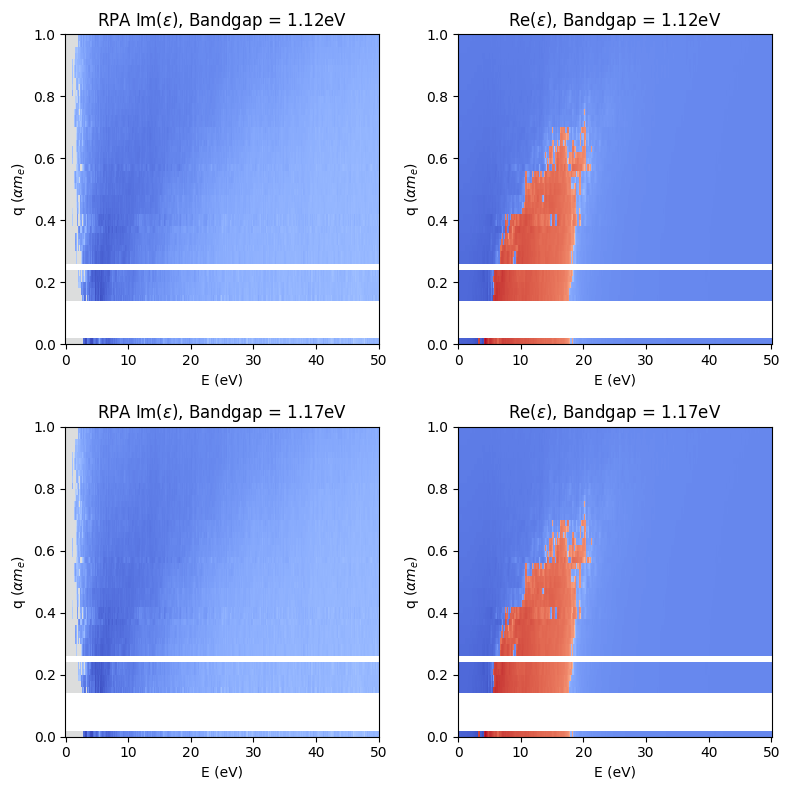

In [57]:
#Testing different bandgaps
q = np.arange(0.01, 1, parmt.dq) #alpha me
E = np.arange(0, 50+parmt.dE, parmt.dE) #eV

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.12_1q_50E.npy') #6x6x6 -> 6x6x6
binned_eps = (np.real(binned_eps)-1)*10/4/np.pi+1 + 1j*np.imag(binned_eps)*10/4/np.pi
bin_centers = gen_bin_centers(q_max=1)
eps_112 = epsilon_r(bin_centers, binned_eps)

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.12_1q_50E.npy') #6x6x6 -> 6x6x6
binned_eps = (np.real(binned_eps)-1)*10/4/np.pi+1 + 1j*np.imag(binned_eps)*10/4/np.pi
bin_centers = gen_bin_centers(q_max=1)
eps_117 = epsilon_r(bin_centers, binned_eps)

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_112[np.invert(np.isnan(eps_112))]))
re_max = np.max(np.real(eps_112[np.invert(np.isnan(eps_112))]))
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(2, 2, figsize=(8,8))

im0 = ax[(0,0)].pcolormesh(E, q, np.imag(eps_112), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(0,1)].pcolormesh(E, q, np.real(eps_112), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[(1,0)].pcolormesh(E, q, np.imag(eps_117), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E, q, np.real(eps_117), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[(0,0)].set_title(r'RPA Im($\epsilon$), Bandgap = 1.12eV')
ax[(0,1)].set_title(r'Re($\epsilon$), Bandgap = 1.12eV')
ax[(1,0)].set_title(r'RPA Im($\epsilon$), Bandgap = 1.17eV')
ax[(1,1)].set_title(r'Re($\epsilon$), Bandgap = 1.17eV')

for i in [0,1]:
    for j in [0,1]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

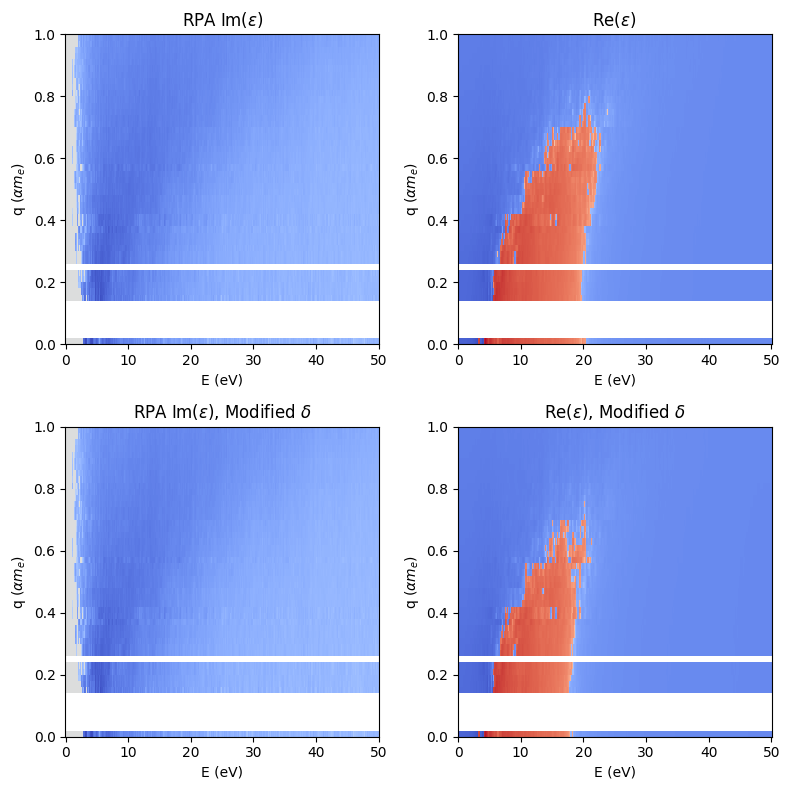

In [59]:
#Delta function is wrong? Are we off by factor of 1/dE = 10 on Im(eps)? - Yes! And have extra 4pi from natural units -> cgs conversion
from epsilon_routines import kramerskronig
q = np.arange(0.01, 1, parmt.dq) #alpha me
E = np.arange(0, 50+parmt.dE, parmt.dE) #eV

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.12_1q_50E.npy') #6x6x6 -> 6x6x6
bin_centers = gen_bin_centers(q_max=1)
eps = epsilon_r(bin_centers, binned_eps)

binned_eps_im = np.imag(binned_eps)/parmt.dE/4/np.pi
binned_eps_re = kramerskronig(binned_eps_im)
eps_dE = epsilon_r(bin_centers, binned_eps_re + 1j*binned_eps_im)

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps[np.invert(np.isnan(eps))]))
re_max = np.max(np.real(eps[np.invert(np.isnan(eps))]))
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(2, 2, figsize=(8,8))

im0 = ax[(0,0)].pcolormesh(E, q, np.imag(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(0,1)].pcolormesh(E, q, np.real(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[(1,0)].pcolormesh(E, q, np.imag(eps_dE), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E, q, np.real(eps_dE), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[(0,0)].set_title(r'RPA Im($\epsilon$)')
ax[(0,1)].set_title(r'Re($\epsilon$)')
ax[(1,0)].set_title(r'RPA Im($\epsilon$), Modified $\delta$')
ax[(1,1)].set_title(r'Re($\epsilon$), Modified $\delta$')

for i in [0,1]:
    for j in [0,1]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

/home/meganhott/Research/dielectric_pyscf/epsilon_routines.py:258: RuntimeWarning: invalid value encountered in divide
  eps_r[i] = np.nansum(eps_ri, axis=0) / (N_ang_bins - np.sum(np.isnan(eps_ri).astype(int), axis=0)) #treats nans as 0, want to average over all non-nan entries


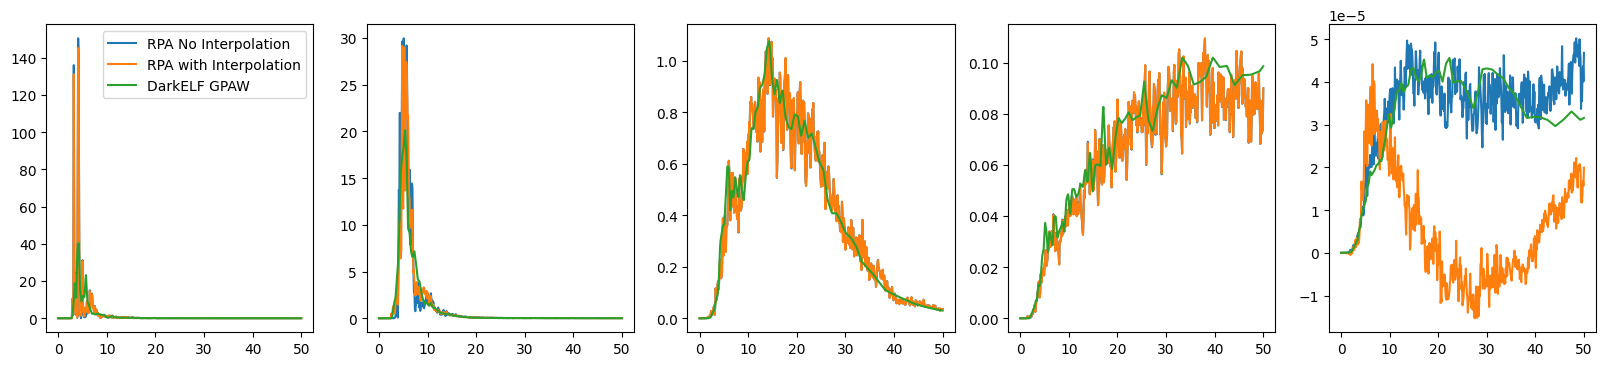

In [67]:
#GPAW vs RPA with 1/parmt.dE factor and comparing to interpolated
from scipy.interpolate import RBFInterpolator

q = np.arange(0.01, 5, parmt.dq) #alpha me
E = np.arange(0, 50+parmt.dE, parmt.dE) #eV

binned_eps = 10*np.imag(np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_5q_50E_old.npy')) #6x6x6 -> 6x6x6
bin_centers = gen_bin_centers(q_max=5)
eps_6_5q = epsilon_r(bin_centers, binned_eps, eps_dtype='float')

#interpolated bins before angular averaging
bin_centers_cart = spherical_to_cartesian(bin_centers) #need cartesian coordinates for interpolator
eps_r_im = epsilon_r(bin_centers, binned_eps, eps_dtype='float')

N_ang_bins = (parmt.N_phi*(parmt.N_theta-2)+2)
binned_eps = binned_eps[:-N_ang_bins] #get rid of extra bins

#nan indices:
nan_loc = np.where(np.isnan(binned_eps[:,0]))[0] #if data is missing for bin, then all energies will be nan so only need to check one of them
interp_loc = np.where(np.invert(np.isnan(binned_eps[:,0])))[0]

nan_bins = bin_centers_cart[nan_loc]

interp_bins = bin_centers_cart[interp_loc]
interp_eps = binned_eps[interp_loc]

interp = RBFInterpolator(interp_bins, interp_eps, kernel='thin_plate_spline')(nan_bins)
binned_eps[nan_loc] = interp #replace nans with interpolated data
eps_int_r_im = epsilon_r(bin_centers, binned_eps, eps_dtype='float')
eps_int_r_re = kramerskronig(eps_int_r_im)

fig, ax = plt.subplots(1,5, figsize=(20,4))

ax[0].plot(E, eps_6_5q[0,:], label='RPA No Interpolation')
ax[0].plot(E, eps_int_r_im[0,:], label='RPA with Interpolation')
ax[0].plot(E, darkelf_gpaw.eps2(E, 0.0057*alpha*mElectron), label='DarkELF GPAW')
ax[1].plot(E, eps_6_5q[int(0.2/parmt.dq),:], label='RPA No Interpolation')
ax[1].plot(E, eps_int_r_im[int(0.2/parmt.dq),:], label='RPA with Interpolation')
ax[1].plot(E, darkelf_gpaw.eps2(E, 0.2*alpha*mElectron), label='DarkELF GPAW')
ax[2].plot(E, eps_6_5q[int(1/parmt.dq),:], label='RPA No Interpolation')
ax[2].plot(E, eps_int_r_im[int(1/parmt.dq),:], label='RPA with Interpolation')
ax[2].plot(E, darkelf_gpaw.eps2(E, 1*alpha*mElectron), label='DarkELF GPAW')
ax[3].plot(E, eps_6_5q[int(2/parmt.dq),:], label='RPA No Interpolation')
ax[3].plot(E, eps_int_r_im[int(2/parmt.dq),:], label='RPA with Interpolation')
ax[3].plot(E, darkelf_gpaw.eps2(E, 2*alpha*mElectron), label='DarkELF GPAW')
ax[4].plot(E, eps_6_5q[-1,:], label='RPA No Interpolation')
ax[4].plot(E, eps_int_r_im[-1,:], label='RPA with Interpolation')
ax[4].plot(E, darkelf_gpaw.eps2(E, 5*alpha*mElectron), label='DarkELF GPAW')
ax[0].legend()

plt.show()


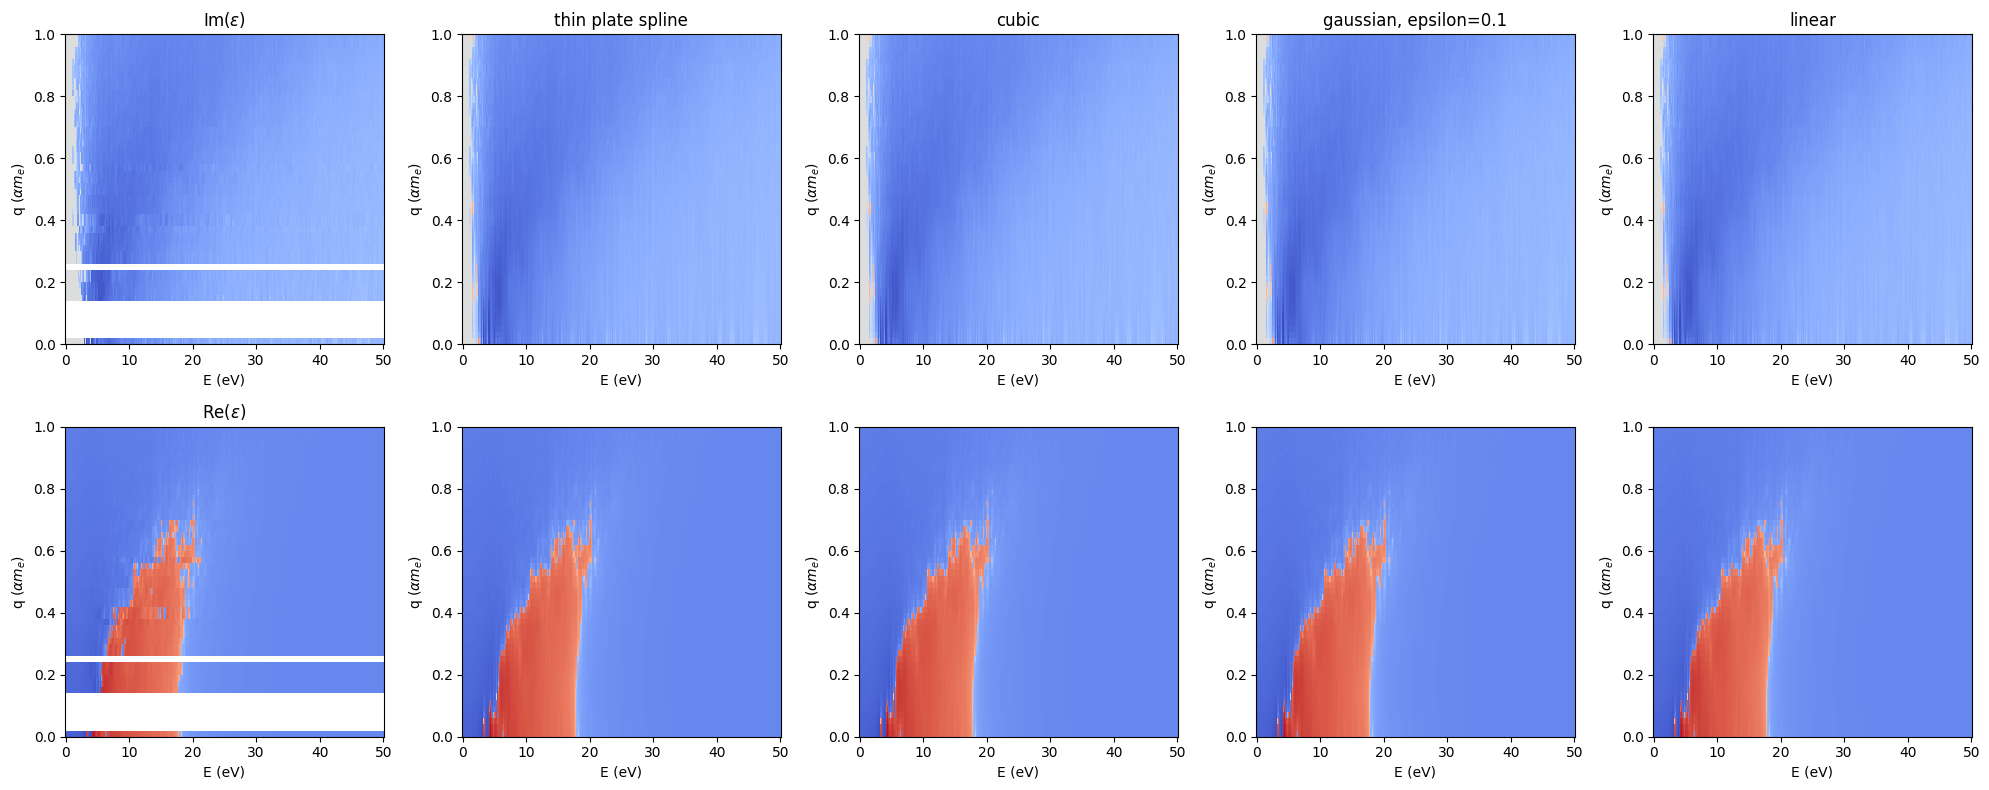

In [110]:
#Interpolation test on 6x6x6
from interp import main
main()

#Need to figure out how to contrain Im(eps) interpolation to > 0

/home/meganhott/Research/dielectric_pyscf/epsilon_routines.py:258: RuntimeWarning: invalid value encountered in divide
  eps_r[i] = np.nansum(eps_ri, axis=0) / (N_ang_bins - np.sum(np.isnan(eps_ri).astype(int), axis=0)) #treats nans as 0, want to average over all non-nan entries


-0.01105847799545426


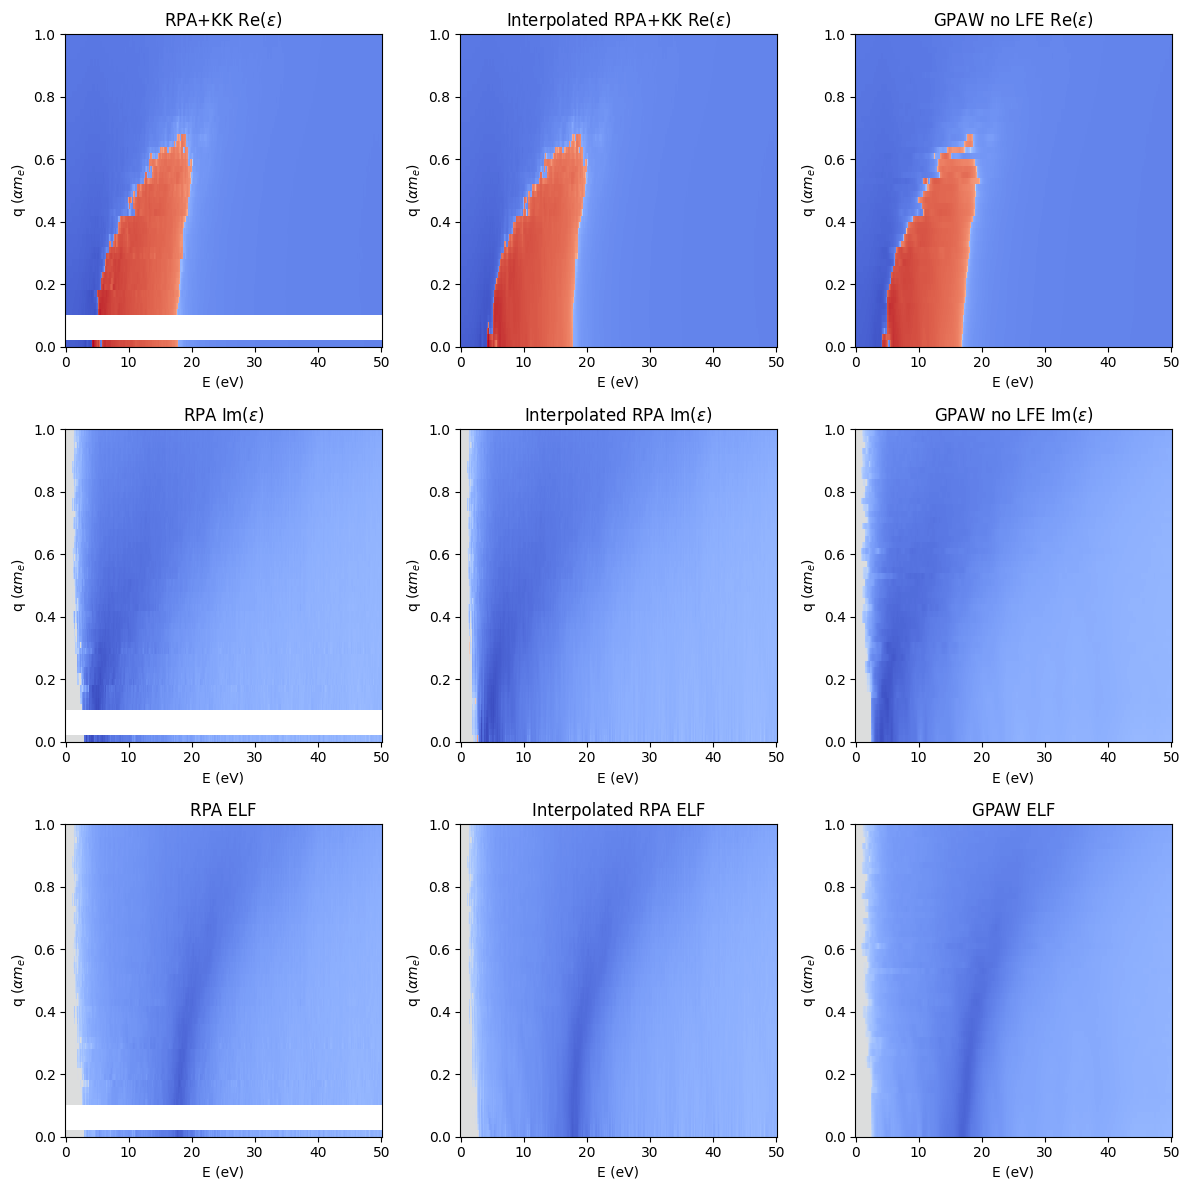

In [112]:
#Comparison to GPAW after prefactor fixed
def elf(eps):
    return np.imag(eps)/((np.imag(eps))**2+np.real(eps)**2)

q = np.arange(0.01, 1, parmt.dq) #alpha me
E = np.arange(0, 50+parmt.dE, parmt.dE) #eV

binned_eps_im = 10*np.imag(np.load('test_resources/binned_eps/cc-pvtz_pbe_8_bg1.10_1q_50E_old.npy')) #8x8x8 -> 8x8x8
binned_eps = kramerskronig(binned_eps_im) + 1j*binned_eps_im
bin_centers = gen_bin_centers(q_max=1)
eps_8 = epsilon_r(bin_centers, binned_eps)

#Interpolated RPA
bin_centers_cart = spherical_to_cartesian(bin_centers) #need cartesian coordinates for interpolator

N_ang_bins = (parmt.N_phi*(parmt.N_theta-2)+2)
binned_eps_im = binned_eps_im[:-N_ang_bins] #get rid of extra bins

nan_loc = np.where(np.isnan(binned_eps_im[:,0]))[0] #if data is missing for bin, then all energies will be nan so only need to check one of them
interp_loc = np.where(np.invert(np.isnan(binned_eps_im[:,0])))[0]

nan_bins = bin_centers_cart[nan_loc]

interp_bins = bin_centers_cart[interp_loc]
interp_eps = binned_eps_im[interp_loc]

interp = RBFInterpolator(interp_bins, interp_eps, kernel='thin_plate_spline')(nan_bins)
binned_eps_im[nan_loc] = interp #replace nans with interpolated data
eps_int_r_im = epsilon_r(bin_centers, binned_eps_im, eps_dtype='float')
eps_int_r_re = kramerskronig(eps_int_r_im)
print(np.min(eps_int_r_im))
c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_8[np.invert(np.isnan(eps_8))]))
re_max = np.min(np.real(eps_8[np.invert(np.isnan(eps_8))]))
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(3,3, figsize=(12,12))

im0 = ax[(0,0)].pcolormesh(E, q, np.real(eps_8), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,0)].pcolormesh(E, q, np.imag(eps_8), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im6 = ax[(2,0)].pcolormesh(E, q, elf(eps_8), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[(0,1)].pcolormesh(E, q, eps_int_r_re, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E, q, eps_int_r_im, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im7 = ax[(2,1)].pcolormesh(E, q, elf(eps_int_r_re + 1j*eps_int_r_im), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im4 = ax[(0,2)].pcolormesh(E, q, darkelf_gpaw.eps1(E, q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im5 = ax[(1,2)].pcolormesh(E, q, darkelf_gpaw.eps2(E, q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im8 = ax[(2,2)].pcolormesh(E, q, elf(darkelf_gpaw.eps1(E, q*alpha*mElectron) + 1j*darkelf_gpaw.eps2(E, q*alpha*mElectron)), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[(0,0)].set_title(r'RPA+KK Re($\epsilon$)')
ax[(1,0)].set_title(r'RPA Im($\epsilon$)')
ax[(2,0)].set_title('RPA ELF')

ax[(0,1)].set_title(r'Interpolated RPA+KK Re($\epsilon$)')
ax[(1,1)].set_title(r'Interpolated RPA Im($\epsilon$)')
ax[(2,1)].set_title('Interpolated RPA ELF')

ax[(0,2)].set_title(r'GPAW no LFE Re($\epsilon$)')
ax[(1,2)].set_title(r'GPAW no LFE Im($\epsilon$)')
ax[(2,2)].set_title('GPAW ELF')

for i in [0,1,2]:
    for j in [0,1,2]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

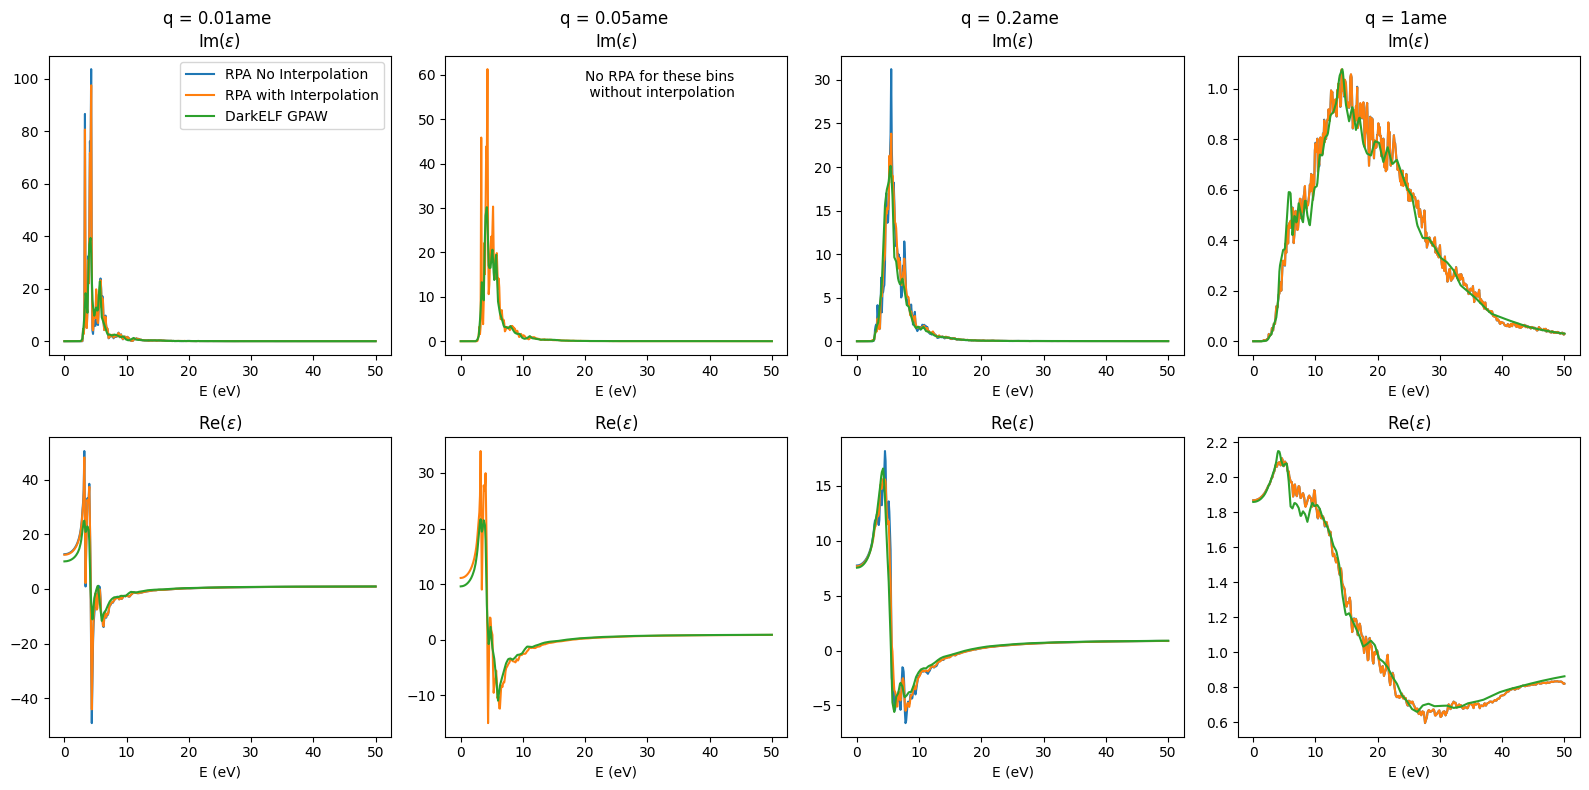

In [90]:
fig, ax = plt.subplots(2,4, figsize=(16,8))

ax[(0,0)].plot(E, np.imag(eps_8)[0,:], label='RPA No Interpolation')
ax[(0,0)].plot(E, eps_int_r_im[0,:], label='RPA with Interpolation')
ax[(0,0)].plot(E, darkelf_gpaw.eps2(E, 0.01*alpha*mElectron), label='DarkELF GPAW')
ax[(0,0)].set_title('q = 0.01ame \n'+r'Im($\epsilon$)')
ax[(0,0)].legend()
ax[(1,0)].plot(E, np.real(eps_8)[0,:], label='RPA No Interpolation')
ax[(1,0)].plot(E, eps_int_r_re[0,:], label='RPA with Interpolation')
ax[(1,0)].plot(E, darkelf_gpaw.eps1(E, 0.01*alpha*mElectron), label='DarkELF GPAW')
ax[(1,0)].set_title(r'Re($\epsilon$)')

ax[(0,1)].plot(E, np.imag(eps_8)[int(0.05/parmt.dq),:], label='RPA No Interpolation')
ax[(0,1)].plot(E, eps_int_r_im[int(0.05/parmt.dq),:], label='RPA with Interpolation')
ax[(0,1)].plot(E, darkelf_gpaw.eps2(E, 0.05*alpha*mElectron), label='DarkELF GPAW')
ax[(0,1)].set_title('q = 0.05ame \n'+r'Im($\epsilon$)')
ax[(0,1)].text(20, 55, 'No RPA for these bins \n without interpolation')
ax[(1,1)].plot(E, np.real(eps_8)[int(0.05/parmt.dq),:], label='RPA No Interpolation')
ax[(1,1)].plot(E, eps_int_r_re[int(0.05/parmt.dq),:], label='RPA with Interpolation')
ax[(1,1)].plot(E, darkelf_gpaw.eps1(E, 0.05*alpha*mElectron), label='DarkELF GPAW')
ax[(1,1)].set_title(r'Re($\epsilon$)')

ax[(0,2)].plot(E, np.imag(eps_8)[int(0.2/parmt.dq),:], label='RPA No Interpolation')
ax[(0,2)].plot(E, eps_int_r_im[int(0.2/parmt.dq),:], label='RPA with Interpolation')
ax[(0,2)].plot(E, darkelf_gpaw.eps2(E, 0.2*alpha*mElectron), label='DarkELF GPAW')
ax[(0,2)].set_title('q = 0.2ame \n'+r'Im($\epsilon$)')
ax[(1,2)].plot(E, np.real(eps_8)[int(0.2/parmt.dq),:], label='RPA No Interpolation')
ax[(1,2)].plot(E, eps_int_r_re[int(0.2/parmt.dq),:], label='RPA with Interpolation')
ax[(1,2)].plot(E, darkelf_gpaw.eps1(E, 0.2*alpha*mElectron), label='DarkELF GPAW')
ax[(1,2)].set_title(r'Re($\epsilon$)')

ax[(0,3)].plot(E, np.imag(eps_8)[-1,:], label='RPA No Interpolation')
ax[(0,3)].plot(E, eps_int_r_im[-1,:], label='RPA with Interpolation')
ax[(0,3)].plot(E, darkelf_gpaw.eps2(E, 1*alpha*mElectron), label='DarkELF GPAW')
ax[(0,3)].set_title('q = 1ame \n'+r'Im($\epsilon$)')
ax[(1,3)].plot(E, np.real(eps_8)[-1,:], label='RPA No Interpolation')
ax[(1,3)].plot(E, eps_int_r_re[-1,:], label='RPA with Interpolation')
ax[(1,3)].plot(E, darkelf_gpaw.eps1(E, 1*alpha*mElectron), label='DarkELF GPAW')
ax[(1,3)].set_title(r'Re($\epsilon$)')

for i in [0,1]:
    for j in [0,1,2,3]:
        ax[(i,j)].set_xlabel('E (eV)')

plt.tight_layout()

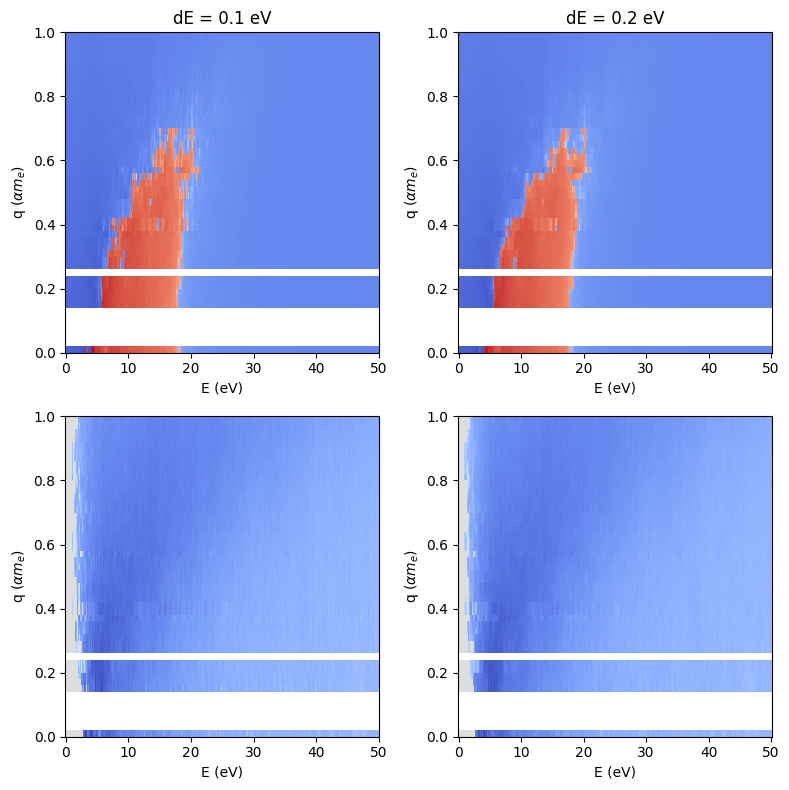

In [109]:
#Testing new code with 1/dE factor - still see same plasmon frequency so we do need this factor!
fig, ax = plt.subplots(2, 2, figsize=(8,8))

#dE = 0.1eV
q = np.arange(0.01, 1, parmt.dq) #alpha me
E = np.arange(0, 50+0.1, 0.1) #eV
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.12_1q_50E.npy')
binned_eps = (np.real(binned_eps)-1)*10/4/np.pi+1 + 1j*np.imag(binned_eps)*10/4/np.pi
bin_centers = gen_bin_centers(q_max=1)
eps_1 = epsilon_r(bin_centers, binned_eps)

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_1[np.invert(np.isnan(eps_1))]))
re_max = np.min(np.real(eps_1[np.invert(np.isnan(eps_1))]))
re_max = max(-1*re_min, re_max)

im0 = ax[(0,0)].pcolormesh(E, q, np.real(eps_1), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,0)].pcolormesh(E, q, np.imag(eps_1), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,))
ax[(0,0)].set_title('dE = 0.1 eV')

#dE = 0.2eV
q = np.arange(0.01, 1, parmt.dq) #alpha me
E = np.arange(0, 50+0.2, 0.2) #eV
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.12_1q_50E_0.2dE.npy')
bin_centers = gen_bin_centers(q_max=1)
eps_2 = epsilon_r(bin_centers, binned_eps)

im2 = ax[(0,1)].pcolormesh(E, q, np.real(eps_2), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E, q, np.imag(eps_2), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,))
ax[(0,1)].set_title('dE = 0.2 eV')

for i in [0,1]:
    for j in [0,1]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

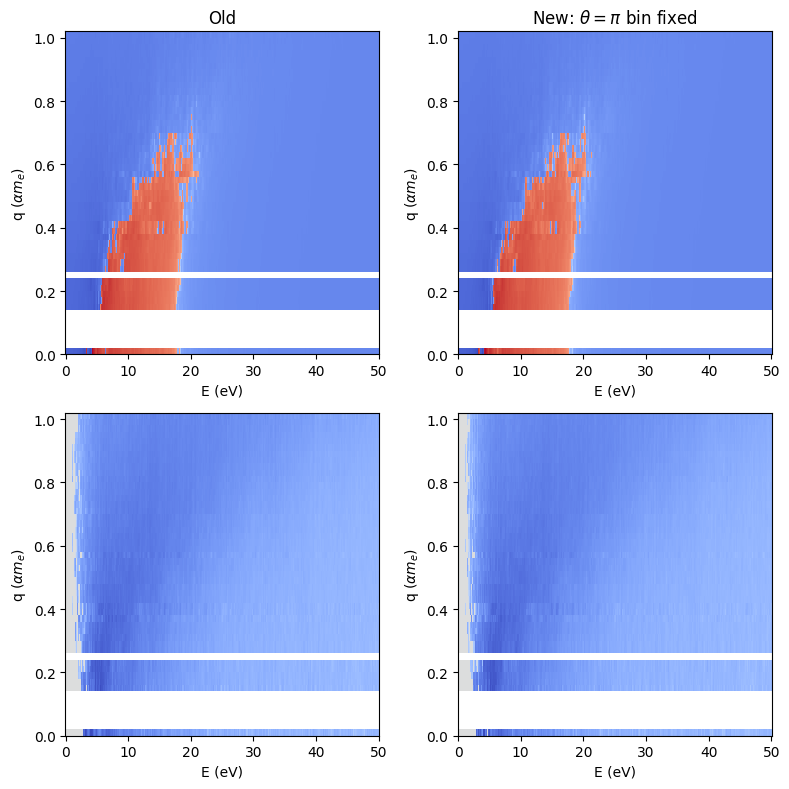

In [13]:
#Fixing theta = pi bin
fig, ax = plt.subplots(2, 2, figsize=(8,8))

#old
q = np.arange(0.01, 1.03, 0.02) #alpha me
E = np.arange(0, 50+0.1, 0.1) #eV
binned_eps_im = 10*np.imag(np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_1q_50E_old.npy'))
binned_eps = kramerskronig(binned_eps_im) + 1j*binned_eps_im
bin_centers = gen_bin_centers(q_max=1)
eps_1 = epsilon_r(bin_centers, binned_eps)

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_1[np.invert(np.isnan(eps_1))]))
re_max = np.min(np.real(eps_1[np.invert(np.isnan(eps_1))]))
re_max = max(-1*re_min, re_max)

im0 = ax[(0,0)].pcolormesh(E, q, np.real(eps_1), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,0)].pcolormesh(E, q, np.imag(eps_1), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
ax[(0,0)].set_title('Old')

#new: binning fixed
q = np.arange(0.01, 1+1.5*parmt.dq, parmt.dq) #alpha me
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_1q_50E_fixbin.npy')
bin_centers = gen_bin_centers(q_max=1)
eps_2 = epsilon_r(bin_centers, binned_eps)

im2 = ax[(0,1)].pcolormesh(E, q, np.real(eps_2), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E, q, np.imag(eps_2), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
ax[(0,1)].set_title(r'New: $\theta = \pi$ bin fixed')

for i in [0,1]:
    for j in [0,1]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()